In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from src.data import create_generators
from src.model import build_model
from src.train import train_model
from src.evaluate import evaluate_model
from src.visualize import show_portfolio
from src.config import *
  


In [4]:
#Load data

train_gen, val_gen, test_gen = create_generators(
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
)

Found 280 images belonging to 4 classes.


Found 60 images belonging to 4 classes.
Found 60 images belonging to 4 classes.


In [5]:
#Build the model

model = build_model(NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
#Train the model

history = train_model(model, train_gen, val_gen)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 330ms/step - accuracy: 0.3607 - loss: 1.3696 - val_accuracy: 0.6167 - val_loss: 1.0425
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.5464 - loss: 1.0417 - val_accuracy: 0.7000 - val_loss: 0.8546
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.6714 - loss: 0.8100 - val_accuracy: 0.7333 - val_loss: 0.7228
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.7500 - loss: 0.7105 - val_accuracy: 0.8167 - val_loss: 0.6275
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.8036 - loss: 0.6006 - val_accuracy: 0.8667 - val_loss: 0.5539
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.8179 - loss: 0.5339 - val_accuracy: 0.8833 - val_loss: 0.4968
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.8036 - loss: 0.5242 - val_accuracy: 0.8833 - val_loss: 0.4727
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.8607 - loss: 0.4396 - val_accuracy: 0.

In [7]:
#Evaluate the model

evaluate_model(model, test_gen)

Starting evaluation...
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 390ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.63      0.80      0.71        15
           2       0.93      0.87      0.90        15
           3       0.75      0.60      0.67        15

    accuracy                           0.80        60
   macro avg       0.81      0.80      0.80        60
weighted avg       0.81      0.80      0.80        60


Results saved to: models/results_20260302_204408.json
Confusion matrix saved to: models/confusion_matrix_20260302_204408.png


(0.8,
 {'0': {'precision': 0.9333333333333333,
   'recall': 0.9333333333333333,
   'f1-score': 0.9333333333333333,
   'support': 15.0},
  '1': {'precision': 0.631578947368421,
   'recall': 0.8,
   'f1-score': 0.7058823529411765,
   'support': 15.0},
  '2': {'precision': 0.9285714285714286,
   'recall': 0.8666666666666667,
   'f1-score': 0.896551724137931,
   'support': 15.0},
  '3': {'precision': 0.75,
   'recall': 0.6,
   'f1-score': 0.6666666666666666,
   'support': 15.0},
  'accuracy': 0.8,
  'macro avg': {'precision': 0.8108709273182957,
   'recall': 0.8,
   'f1-score': 0.8006085192697768,
   'support': 60.0},
  'weighted avg': {'precision': 0.8108709273182958,
   'recall': 0.8,
   'f1-score': 0.8006085192697768,
   'support': 60.0}},
 array([[14,  0,  0,  1],
        [ 1, 12,  0,  2],
        [ 0,  2, 13,  0],
        [ 0,  5,  1,  9]]))

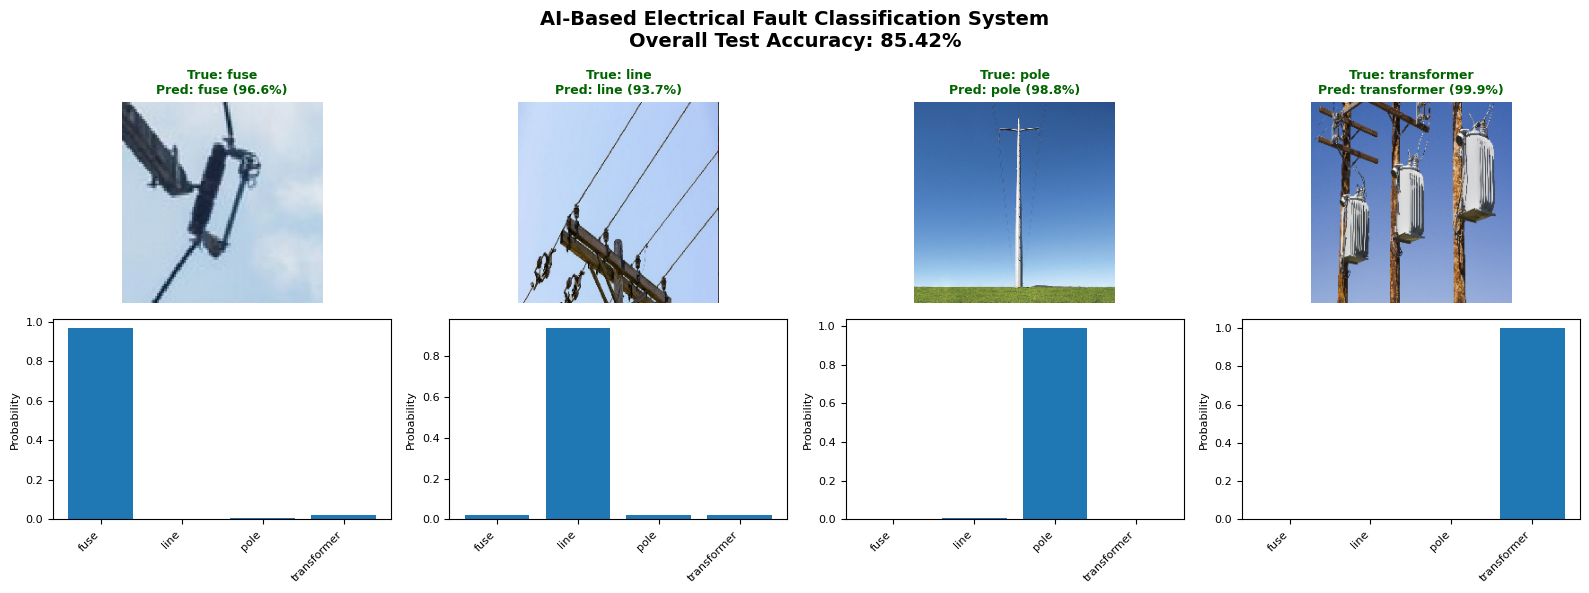

Professional IEEE-style figure saved as: Sample per class.png


In [8]:

show_portfolio(model, test_gen)